# Dynamische Netzentgelte aus Day-Ahead Preisen

Dieses Notebook nutzt `electricity_price_2025.csv` in 15-Minuten-Aufloesung und vergleicht mehrere Methodiken zur Fensterbestimmung.

## Aufbau

1. Daten laden und vorbereiten
2. TopN-Varianten (1/1 und 2/2 Peaks)
3. Quantil-Kontingent (distributed vs contiguous)
4. Variantenvergleich und Visualisierung
5. Lastlinear (`LoadLinearDailyMethod`) und Abonnement-Kapazität (`SubscriptionCapacityMethod`)

## Output-Spalten

- `window_flag` (`0=normal`, `1=low`, `2=high`)
- `is_low_window` (`0/1`)
- `is_high_window` (`0/1`)
- `grid_fee` (parametrisierte Rabatte/Aufschlaege; bei Abonnement-Methode plus optionale Spalten `penalty_threshold_kw`, `penalty_rate_per_kw`)

| Methode                     | Input-Signal                      | Lastgang nötig?    | Kreisabhängigkeit möglich? |
| --------------------------- | --------------------------------- | ------------------ | -------------------------- |
| TopNPeakReferenceDayMethod  | Day-Ahead-Preis, exogene Netzlast (PV) | Nein                  | Nein                          |
| QuantileDailyBudgetMethod   | Day-Ahead-Preis, exogene Netzlast (PV) | Nein                  | Nein                          |
| LoadLinearDailyMethod       | exogene Netzlast (PV)                    | nur wenn exogen | nur wenn endogene Last      |
| SubscriptionCapacityMethod  | optional (wird nicht genutzt) | Nein           | Nein                          |
| Variante A (ex-post Stufen) | Gemessener Verbrauchslastgang     | Ja                  | Ja, kritisch                 |
| Variante B (Abonnement)     | Keine Zeitreihe, nur Stufe        | Nein                  | Nein                          |

## Modul 3 § 14a — H0-/SLP-Neutralität (automatisch)

**BDEW-Nebenbedingung (vereinfacht):** Ein Kunde mit Standardlastprofil soll durch den **zeitvariablen** Tarif nicht automatisch günstiger sein als mit **pauschalem** Netzentgelt (ST ≈ `base_fee`). Der Vorteil soll aus **Lastverschiebung** kommen.

`generate_grid_fee_timeseries` führt den Check **standardmäßig** aus (Gewichte aus `profile_bdew.xlsx`, Blatt `H25` = Haushalt). Bei Verletzung erscheint nur eine **`UserWarning`** — keine zusätzlichen Spalten im Ergebnis.

$$\sum_t w^{\mathrm{H0}}_t \cdot \mathrm{grid\_fee}(t) \;\ge\; P^{\mathrm{pauschal}}$$

In [1]:
from pathlib import Path

import pandas as pd

from grid_fee import (
    TopNPeakReferenceDayMethod,
    generate_grid_fee_timeseries,
    QuantileDailyBudgetMethod,
    LoadLinearDailyMethod,
    SubscriptionCapacityMethod,
)

In [2]:
# 1) Daten laden und vorbereiten
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
csv_path = project_root / "electricity_price_2025.csv"

raw = pd.read_csv(csv_path)
raw["timestamp"] = pd.to_datetime(raw["timestamp"], utc=True)
raw["price"] = pd.to_numeric(raw["price"], errors="coerce")

df = raw[["timestamp", "price"]].rename(columns={"price": "market_price"})
df.head()

,timestamp,market_price
0,2025-01-01 00:00:00+00:00,1.6
1,2025-01-01 00:15:00+00:00,1.6
2,2025-01-01 00:30:00+00:00,1.6
3,2025-01-01 00:45:00+00:00,1.6
4,2025-01-01 01:00:00+00:00,0.0


## Mathematische Definition: `TopNPeakReferenceDayMethod`

**Idee:** Pro Tag werden die $N_\text{low}$ niedrigsten und $N_\text{high}$ höchsten Signalwerte (Peaks) gesucht. Um jeden **Low-**Peak wird ein Fenster der Länge $W_\text{low}$ Stunden gelegt, um jeden **High-**Peak eines der Länge $W_\text{high}$. Zeitpunkte innerhalb dieser Fenster erhalten ein reduziertes (Low) oder erhöhtes (High) Netzentgelt.

### Notation

| Symbol | Bedeutung |
|---|---|
| $j$ | Tag |
| $t$ | Zeitpunkt innerhalb des Tages (z. B. 15-min-Schritte) |
| $s_{tj}$ | Eingangssignal zum Zeitpunkt $t$ an Tag $j$ (z. B. Day-Ahead-Preis) |
| $W_\text{low}$ | Fensterlänge in Stunden (Low-Peaks) |
| $W_\text{high}$ | Fensterlänge in Stunden (High-Peaks) |
| $\mathcal{P}^{\text{low}}_j$ | Menge der ausgewählten Low-Peak-Zeitpunkte an Tag $j$ |
| $\mathcal{P}^{\text{high}}_j$ | Menge der ausgewählten High-Peak-Zeitpunkte an Tag $j$ |
| $P$ | Basis-Netzentgelt |
| $r$ | Relative Reduktion (Discount) |
| $s$ | Relativer Aufschlag (Surcharge) |

### Peak-Auswahl

- $\mathcal{P}^{\text{low}}_j$: die $N_\text{low}$ Zeitpunkte mit den **kleinsten** Signalwerten
- $\mathcal{P}^{\text{high}}_j$: die $N_\text{high}$ Zeitpunkte mit den **größten** Signalwerten
- Nebenbedingungen: jedes Fenster muss vollständig im Kalendertag liegen, Fenster dürfen sich nicht überlappen

### Fensterkonstruktion

Für jeden Low-Peak $\tau$ bzw. High-Peak $\tau'$:

$$I^{\text{low}}(\tau) = \left[\tau - \frac{W_\text{low}}{2},\; \tau + \frac{W_\text{low}}{2}\right)$$

$$I^{\text{high}}(\tau') = \left[\tau' - \frac{W_\text{high}}{2},\; \tau' + \frac{W_\text{high}}{2}\right)$$

Die Low- und High-Indikatoren je Zeitpunkt $t$:

$$L_{tj} = \begin{cases} 1 & \text{wenn } t \in \bigcup_{\tau \in \mathcal{P}^{\text{low}}_j} I^{\text{low}}(\tau) \\ 0 & \text{sonst} \end{cases}$$

$$H_{tj} = \begin{cases} 1 & \text{wenn } t \in \bigcup_{\tau' \in \mathcal{P}^{\text{high}}_j} I^{\text{high}}(\tau') \\ 0 & \text{sonst} \end{cases}$$

**Konfliktregel – Low gewinnt:** Falls $L_{tj} = 1$, wird $H_{tj} = 0$ gesetzt.

### Fenster-Flag

$$\text{flag}_{tj} = \begin{cases} 1 & \text{wenn } L_{tj} = 1 \\ 2 & \text{wenn } H_{tj} = 1 \\ 0 & \text{sonst} \end{cases}$$

### Netzentgelt

$$P_{tj} = \begin{cases} P \cdot (1 - r) & \text{wenn } \text{flag}_{tj} = 1 \quad \text{(Low-Fenster)} \\ P \cdot (1 + s) & \text{wenn } \text{flag}_{tj} = 2 \quad \text{(High-Fenster)} \\ P & \text{sonst} \end{cases}$$

In [3]:
# 2) TopN-Varianten
# Szenario A: 1/1 Peaks pro Tag
method_a = TopNPeakReferenceDayMethod(
    base_fee=12.0,
    relative_fee_reduction=0.6,
    relative_fee_surcharge=0.25,
    n_low_peaks=1,
    n_high_peaks=1,
    window_size_hours_low=4.0,
    window_size_hours_high=4.0,
    time_window_start_hour=0,
    time_window_end_hour=23,
    use_reference_day=False,
)

result_a = generate_grid_fee_timeseries(
    frame=df,
    signal_column="market_price",
    method=method_a,
)

result_a.head(24)

/home/jonathan/Dokumente/coding/grid-fee-ts-generator/src/grid_fee/generator.py:117: UserWarning: H0/SLP neutrality violated (profile H25): weighted average grid fee (11.4675) is below the flat/ST reference (12) by 0.532459. A standard-load-profile customer could pay less than pauschal without load shifting (Modul 3 § 14a / BDEW).
  check_h0_slp_neutrality(


,timestamp,market_price,grid_fee,is_low_window,is_high_window,window_flag,method
0,2025-01-01 00:00:00+00:00,1.60,12.0,0,0,0,topn_peak_reference_day
1,2025-01-01 00:15:00+00:00,1.60,12.0,0,0,0,topn_peak_reference_day
2,2025-01-01 00:30:00+00:00,1.60,12.0,0,0,0,topn_peak_reference_day
3,2025-01-01 00:45:00+00:00,1.60,12.0,0,0,0,topn_peak_reference_day
4,2025-01-01 01:00:00+00:00,0.00,12.0,0,0,0,topn_peak_reference_day
5,2025-01-01 01:15:00+00:00,0.00,12.0,0,0,0,topn_peak_reference_day
6,2025-01-01 01:30:00+00:00,0.00,12.0,0,0,0,topn_peak_reference_day
7,2025-01-01 01:45:00+00:00,0.00,12.0,0,0,0,topn_peak_reference_day
8,2025-01-01 02:00:00+00:00,-0.01,12.0,0,0,0,topn_peak_reference_day
9,2025-01-01 02:15:00+00:00,-0.01,12.0,0,0,0,topn_peak_reference_day


## Mathematische Definition: `QuantileDailyBudgetMethod`

**Idee:** Statt einer festen Anzahl Peaks wird pro Tag ein **Anteil** der Zeitpunkte als Low bzw. High markiert – z. B. die günstigsten 20 % des Tages als Low. Das Budget $q_\text{low}$ und $q_\text{high}$ ist dabei täglich garantiert.

### Notation

| Symbol | Bedeutung |
|---|---|
| $j$ | Tag |
| $t$ | Zeitpunkt innerhalb des Tages |
| $s_{tj}$ | Eingangssignal zum Zeitpunkt $t$ an Tag $j$ |
| $\mathcal{T}_j$ | Anzahl der Zeitpunkte an Tag $j$ |
| $q_\text{low} \in [0,1]$ | Gewünschter Low-Anteil pro Tag |
| $q_\text{high} \in [0,1]$ | Gewünschter High-Anteil pro Tag |
| $K^{\text{low}}_j$ | Anzahl Low-Zeitpunkte an Tag $j$ |
| $K^{\text{high}}_j$ | Anzahl High-Zeitpunkte an Tag $j$ |

### Variante 1: Distributed (verteilte Auswahl)

Die $K^{\text{low}}_j$ Zeitpunkte mit den **kleinsten** Signalwerten werden als Low markiert, die $K^{\text{high}}_j$ Zeitpunkte mit den **größten** Signalwerten als High:

$$L_{tj} = \begin{cases} 1 & \text{wenn } s_{tj} \text{ unter den } K^{\text{low}}_j \text{ kleinsten Tageswerten} \\ 0 & \text{sonst} \end{cases}$$

$$H_{tj} = \begin{cases} 1 & \text{wenn } s_{tj} \text{ unter den } K^{\text{high}}_j \text{ größten Tageswerten} \\ 0 & \text{sonst} \end{cases}$$

Die ausgewählten Zeitpunkte müssen dabei **nicht zusammenhängen**.

### Variante 2: Contiguous (zusammenhängende Blöcke)

Statt Einzelzeitpunkte werden **Blöcke** mit einer Mindestlänge (z. B. 1 h) gesucht. Ein Block wird anhand seines **mittleren Signalwerts** bewertet und greedy ausgewählt:

- Low-Blöcke: Blöcke mit möglichst **niedrigem** Blockmittelwert
- High-Blöcke: Blöcke mit möglichst **hohem** Blockmittelwert
- Maximale Blockanzahl: $B_\text{low}$ bzw. $B_\text{high}$ Blöcke pro Tag

Die Gesamtanzahl markierter Schritte bleibt dabei nah an $K^{\text{low}}_j$ bzw. $K^{\text{high}}_j$.

### Konfliktregel und Flag

Wie bei `TopNPeakReferenceDayMethod` gilt **Low gewinnt**. Danach:

$$\text{flag}_{tj} = \begin{cases} 1 & \text{wenn } L_{tj} = 1 \\ 2 & \text{wenn } H_{tj} = 1 \\ 0 & \text{sonst} \end{cases}$$

### Netzentgelt

$$P_{tj} = \begin{cases} P \cdot (1 - r) & \text{wenn } \text{flag}_{tj} = 1 \quad \text{(Low-Fenster)} \\ P \cdot (1 + s) & \text{wenn } \text{flag}_{tj} = 2 \quad \text{(High-Fenster)} \\ P & \text{sonst} \end{cases}$$

In [4]:
# Szenario B: 2/2 Peaks pro Tag
method_b = TopNPeakReferenceDayMethod(
    base_fee=12.0,
    relative_fee_reduction=0.6,
    relative_fee_surcharge=0.25,
    n_low_peaks=2,
    n_high_peaks=2,
    window_size_hours_low=4.0,
    window_size_hours_high=4.0,
    time_window_start_hour=0,
    time_window_end_hour=23,
    use_reference_day=False,
)
result_b = generate_grid_fee_timeseries(
    frame=df,
    signal_column="market_price",
    method=method_b,
)

# Quantil-Methode: distributed vs contiguous
# 3) Quantil-Kontingent Varianten

quantile_distributed = QuantileDailyBudgetMethod(
    base_fee=12.0,
    relative_fee_reduction=0.6,
    relative_fee_surcharge=0.25,
    q_low=0.2,
    q_high=0.2,
    selection_mode="distributed",
)
quantile_contiguous = QuantileDailyBudgetMethod(
    base_fee=12.0,
    relative_fee_reduction=0.6,
    relative_fee_surcharge=0.25,
    q_low=0.2,
    q_high=0.2,
    selection_mode="contiguous",
    max_blocks_low=2,
    max_blocks_high=2,
    min_block_hours=1.0,
)

result_qd = generate_grid_fee_timeseries(df, signal_column="market_price", method=quantile_distributed)
result_qc = generate_grid_fee_timeseries(df, signal_column="market_price", method=quantile_contiguous)

def flag_counts(result: pd.DataFrame) -> dict:
    counts = result["window_flag"].value_counts().to_dict()
    return {
        "normal_steps": int(counts.get(0, 0)),
        "low_steps": int(counts.get(1, 0)),
        "high_steps": int(counts.get(2, 0)),
    }

# 4) Variantenvergleich
comparison = pd.DataFrame(
    [
        {"scenario": "TopN 1/1", **flag_counts(result_a)},
        {"scenario": "TopN 2/2", **flag_counts(result_b)},
        {"scenario": "Quantile distributed", **flag_counts(result_qd)},
        {"scenario": "Quantile contiguous", **flag_counts(result_qc)},
    ]
)

comparison["active_share"] = (
    comparison["low_steps"] + comparison["high_steps"]
) / (
    comparison["normal_steps"] + comparison["low_steps"] + comparison["high_steps"]
)
comparison

/home/jonathan/Dokumente/coding/grid-fee-ts-generator/src/grid_fee/generator.py:117: UserWarning: H0/SLP neutrality violated (profile H25): weighted average grid fee (10.8044) is below the flat/ST reference (12) by 1.19565. A standard-load-profile customer could pay less than pauschal without load shifting (Modul 3 § 14a / BDEW).
  check_h0_slp_neutrality(
/home/jonathan/Dokumente/coding/grid-fee-ts-generator/src/grid_fee/generator.py:117: UserWarning: H0/SLP neutrality violated (profile H25): weighted average grid fee (11.3923) is below the flat/ST reference (12) by 0.607714. A standard-load-profile customer could pay less than pauschal without load shifting (Modul 3 § 14a / BDEW).
  check_h0_slp_neutrality(
/home/jonathan/Dokumente/coding/grid-fee-ts-generator/src/grid_fee/generator.py:117: UserWarning: H0/SLP neutrality violated (profile H25): weighted average grid fee (11.7681) is below the flat/ST reference (12) by 0.231879. A standard-load-profile customer could pay less than pau

,scenario,normal_steps,low_steps,high_steps,active_share
0,TopN 1/1,23361,5840,5840,0.333324
1,TopN 2/2,11713,11680,11648,0.665734
2,Quantile distributed,21171,6935,6935,0.395822
3,Quantile contiguous,29201,2920,2920,0.166662


Text(0, 0.5, 'flag')

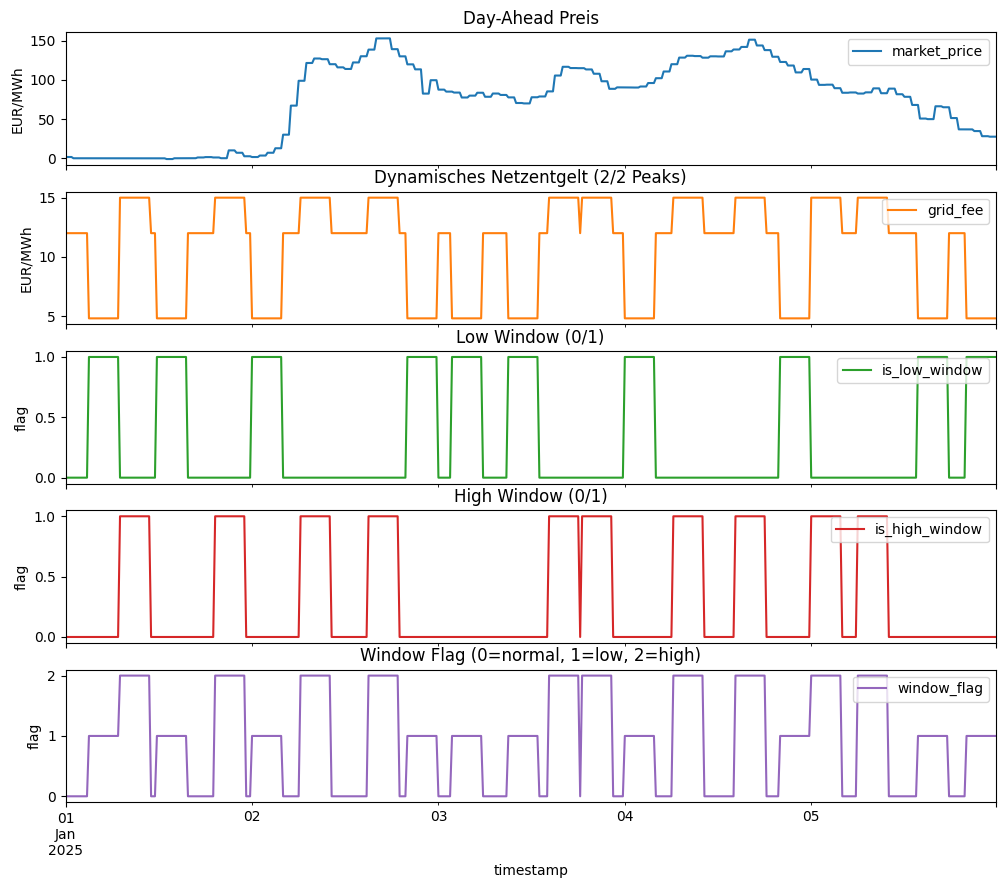

In [5]:
# 5) Visualisierung TopN (Szenario B: 2/2)
steps_per_day = 96
plot_df = result_b.set_index("timestamp")[[
    "market_price",
    "grid_fee",
    "is_low_window",
    "is_high_window",
    "window_flag",
]].iloc[: steps_per_day * 5]
axes = plot_df.plot(
    subplots=True,
    figsize=(12, 10),
    title=[
        "Day-Ahead Preis",
        "Dynamisches Netzentgelt (2/2 Peaks)",
        "Low Window (0/1)",
        "High Window (0/1)",
        "Window Flag (0=normal, 1=low, 2=high)",
    ],
)
axes[0].set_ylabel("EUR/MWh")
axes[1].set_ylabel("EUR/MWh")
axes[2].set_ylabel("flag")
axes[3].set_ylabel("flag")
axes[4].set_ylabel("flag")

Text(0, 0.5, 'flag')

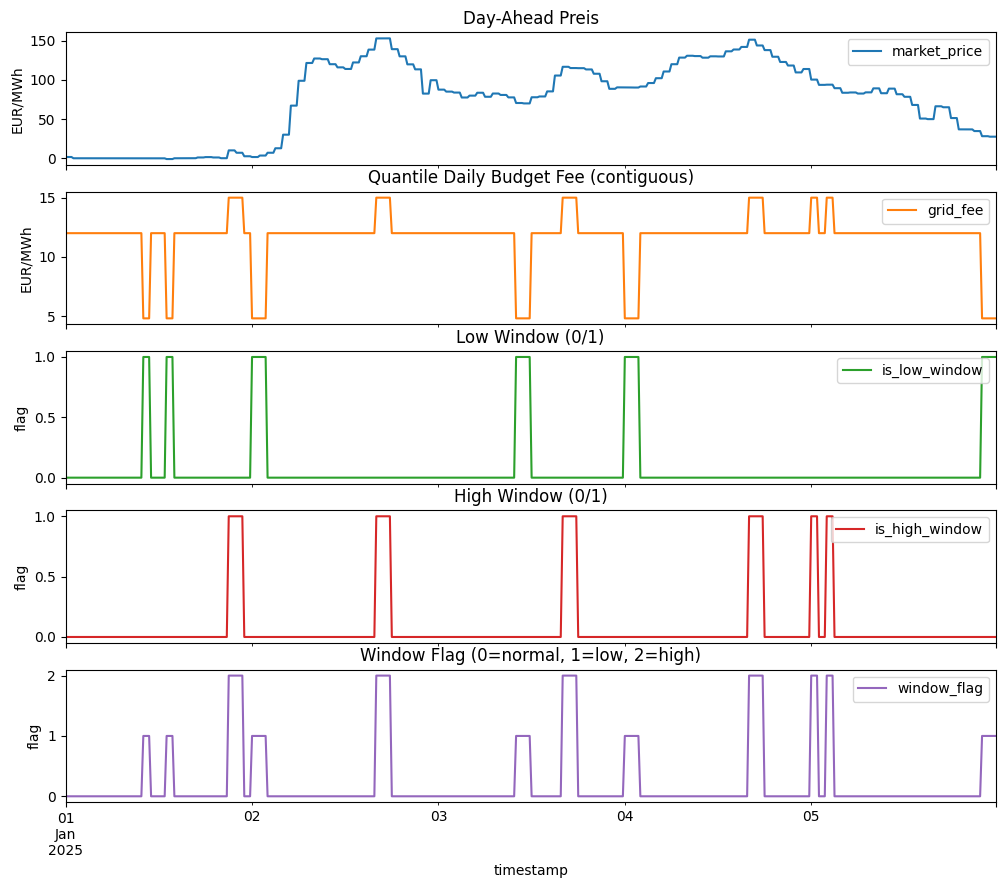

In [6]:
# 6) Visualisierung Quantile (contiguous)
steps_per_day = 96
plot_q = result_qc.set_index("timestamp")[[
    "market_price",
    "grid_fee",
    "is_low_window",
    "is_high_window",
    "window_flag",
]].iloc[: steps_per_day * 5]
axes = plot_q.plot(
    subplots=True,
    figsize=(12, 10),
    title=[
        "Day-Ahead Preis",
        "Quantile Daily Budget Fee (contiguous)",
        "Low Window (0/1)",
        "High Window (0/1)",
        "Window Flag (0=normal, 1=low, 2=high)",
    ],
)
axes[0].set_ylabel("EUR/MWh")
axes[1].set_ylabel("EUR/MWh")
axes[2].set_ylabel("flag")
axes[3].set_ylabel("flag")
axes[4].set_ylabel("flag")

Text(0, 0.5, 'flag')

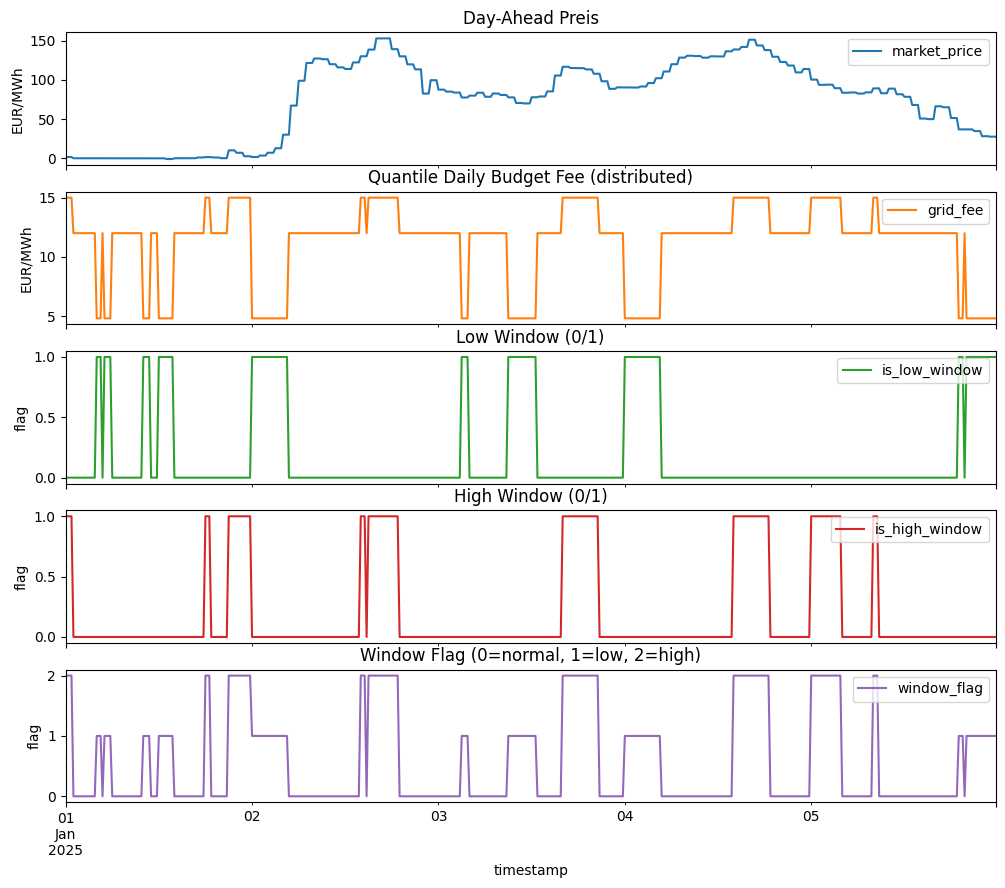

In [7]:
# 7) Visualisierung Quantile (distributed)
steps_per_day = 96
plot_qd = result_qd.set_index("timestamp")[[
    "market_price",
    "grid_fee",
    "is_low_window",
    "is_high_window",
    "window_flag",
]].iloc[: steps_per_day * 5]
axes = plot_qd.plot(
    subplots=True,
    figsize=(12, 10),
    title=[
        "Day-Ahead Preis",
        "Quantile Daily Budget Fee (distributed)",
        "Low Window (0/1)",
        "High Window (0/1)",
        "Window Flag (0=normal, 1=low, 2=high)",
    ],
)
axes[0].set_ylabel("EUR/MWh")
axes[1].set_ylabel("EUR/MWh")
axes[2].set_ylabel("flag")
axes[3].set_ylabel("flag")
axes[4].set_ylabel("flag")

## Lastbasierte dynamische Netzentgelte (LoadLinearDailyMethod)

Dieser Abschnitt liest `grid_load.csv` ein und demonstriert die lastabhängige Preisbildung pro Tag:

- `grid_fee` wird pro Tag linear zwischen `p_min` und `p_max` skaliert.
- basiert auf `net_load` (Netzlast-Zeitreihe).

In [9]:
# Netzlast-CSV laden (deutsches Zahlenformat: Tausenderpunkt + Dezimalkomma)
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
load_path = project_root / "grid_load.csv"

raw_load = pd.read_csv(
    load_path,
    sep=";",
    decimal=",",
    thousands=".",
)

# Wir nutzen den Startzeitpunkt als Timestamp.
raw_load["timestamp"] = pd.to_datetime(raw_load["Datum von"], dayfirst=True, utc=True)
raw_load["net_load"] = pd.to_numeric(raw_load["Netzlast [MWh] Originalauflösungen"], errors="coerce")

# Unser Generator verlangt eindeutige Timestamps.
# Falls die Quelle Duplikate enthält, aggregieren wir (Mittelwert je Zeitpunkt).
load_df = (
    raw_load[["timestamp", "net_load"]]
    .dropna()
    .groupby("timestamp", as_index=False)
    .mean(numeric_only=True)
)

load_df.head()

,timestamp,net_load
0,2025-01-01 00:00:00+00:00,12103.00
1,2025-01-01 00:15:00+00:00,11883.75
2,2025-01-01 00:30:00+00:00,11893.25
3,2025-01-01 00:45:00+00:00,11861.75
4,2025-01-01 01:00:00+00:00,11800.00


In [10]:
# Methode anwenden
load_method = LoadLinearDailyMethod(p_min=10.0, p_max=30.0)

load_result = generate_grid_fee_timeseries(
    frame=load_df,
    signal_column="net_load",
    method=load_method,
)

load_result.head()

,timestamp,net_load,grid_fee,is_low_window,is_high_window,window_flag,method
0,2025-01-01 00:00:00+00:00,12103.00,18.041146,0,0,0,load_linear_daily
1,2025-01-01 00:15:00+00:00,11883.75,16.743136,0,0,0,load_linear_daily
2,2025-01-01 00:30:00+00:00,11893.25,16.799378,0,0,0,load_linear_daily
3,2025-01-01 00:45:00+00:00,11861.75,16.612891,0,0,0,load_linear_daily
4,2025-01-01 01:00:00+00:00,11800.00,16.247317,0,0,0,load_linear_daily


In [11]:
# Plausibilitätscheck pro Tag: min/max sollten p_min/p_max erreichen (wenn Last variiert)
check = (
    load_result.assign(date=load_result["timestamp"].dt.date)
    .groupby("date")["grid_fee"]
    .agg(["min", "max"]) 
    .head(10)
)
check

,min,max
date,,
2025-01-01,10.0,30.0
2025-01-02,10.0,30.0
2025-01-03,10.0,30.0
2025-01-04,10.0,30.0
2025-01-05,10.0,30.0
2025-01-06,10.0,30.0
2025-01-07,10.0,30.0
2025-01-08,10.0,30.0
2025-01-09,10.0,30.0


## Mathematische Definition: `LoadLinearDailyMethod`

**Idee:** Das Netzentgelt folgt linear der Netzlast: hohe Last $\rightarrow$ hohes Entgelt, niedrige Last $\rightarrow$ niedriges Entgelt. Pro Tag wird die Last auf das Intervall $[P_{min}, P_{max}]$ skaliert.

### Notation

| Symbol | Bedeutung |
|---|---|
| $j$ | Tag |
| $t$ | Zeitpunkt innerhalb des Tages |
| $NL_{tj}$ | Netzlast zum Zeitpunkt $t$ an Tag $j$ |
| $NL_j$ | Menge aller Netzlastwerte an Tag $j$ |
| $P_{tj}$ | Netzentgelt zum Zeitpunkt $t$ an Tag $j$ |
| $P_{min},\, P_{max}$ | Untere und obere Entgeltgrenze |

### Formel

$$P_{tj} = \left( NL_{tj} - \min(NL_j) \right) \cdot \frac{P_{max} - P_{min}}{\max(NL_j) - \min(NL_j)} + P_{min}$$

### Spezialfall: konstante Tageslast

Falls $\max(NL_j) = \min(NL_j)$ (keine Lastvariation), ist der Nenner null. In diesem Fall gilt:

$$P_{tj} = P_{min} \quad \forall\, t \in \mathcal{T}_j$$

### Eigenschaften

- **Linear innerhalb des Tages:** Die Abbildung von Last auf Preis ist eine einfache lineare Skalierung.
- **Tagesweise relativ:** Nur die Position eines Zeitpunkts *innerhalb* des Tagesprofils zählt – ein generell lastarmer Tag wird nicht automatisch günstiger als ein laststarker Tag.
- **Kein diskretes Flag:** Anders als bei den anderen Methoden gibt es keine Low/High-Fenster – `window_flag` ist immer 0.

Text(0, 0.5, 'EUR/MWh')

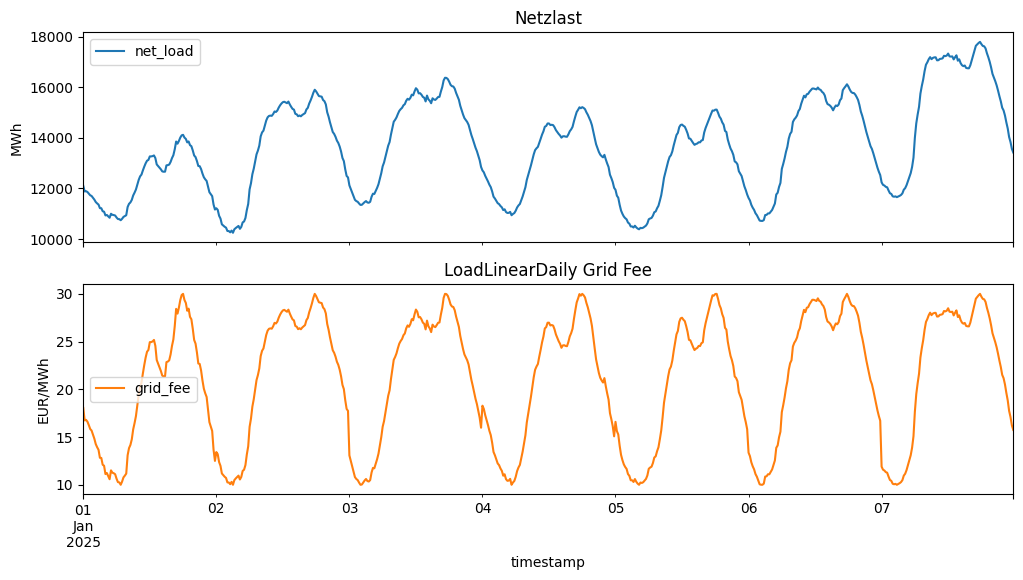

In [12]:
# Visualisierung (erste 7 Tage)
steps_per_day = 96  # 15-min Daten
plot_load = load_result.set_index("timestamp")[["net_load", "grid_fee"]].iloc[: steps_per_day * 7]
axes = plot_load.plot(subplots=True, figsize=(12, 6), title=["Netzlast", "LoadLinearDaily Grid Fee"])
axes[0].set_ylabel("MWh")
axes[1].set_ylabel("EUR/MWh")

## Abonnement-Kapazität (`SubscriptionCapacityMethod`)

**Idee (frankreich-nah, *puissance souscrite*):** Der Netzbetrieb und der Kunde vereinbaren **vorab** eine Leistungsstufe mit Obergrenze $P^{\mathrm{sub}}$ und Basisentgelt $f^{\mathrm{base}}$. Überschreitungen werden typischerweise **linear** im Überhang $(P - P^{\mathrm{sub}})_+$ bepreist.

**Kausalität:** Dieses Paket vermeidet die Rückkopplung „gemessene Last $\rightarrow$ Entgelt $\rightarrow$ Last“. Die Methode nutzt die **Eingangs-Signalspalte nicht** (sie ist für das Protokoll optional weglassbar): `generate_grid_fee_timeseries(..., signal_column=None)` mit einem DataFrame, der **nur** `timestamp` enthält, reicht aus (`uses_input_signal=False`). So entsteht keine falsche Erwartung, die Lastspalte würde die Gebühr im Generator beeinflussen. Die lineare Strafkomponente setzt ihr **außerhalb** mit eurem $P(t)$ an (Prognose, Szenario, …).

### Konfiguration

- **Tarifmenü:** Paare $(P^{\mathrm{sub}}_i,\, f_i)$ für $i=1,\ldots,k$ als `tier_caps_kw` und `tier_fees` (gleiche Länge, Caps strikt steigend).
- **Wahl:** `subscribed_tier_index` $\in \{1,\ldots,k\}$ (1-basiert) wählt die vertragliche Stufe.
- **`penalty_add`:** Steigung $\Delta$ der linearen Zusatzkomponente (pro kW Überhang; Einheit konsistent zu `grid_fee` wählen, z. B. EUR/MWh pro kW).

### Ausgabe des Generators

| Spalte | Bedeutung |
|--------|-----------|
| `grid_fee` | Konstant $f^{\mathrm{base}}$ für die gewählte Stufe |
| `penalty_threshold_kw` | $P^{\mathrm{sub}}$ (Schwelle in kW) |
| `penalty_rate_per_kw` | $\Delta$ (gleicher Wert wie `penalty_add`) |
| `window_flag` / Low–High | Immer 0 (keine Fensterlogik) |

### Lineare Gesamtgebühr (außerhalb dieses Notebooks / Pakets)

Mit Leistung $P(t)$ in **kW** (exogen zum Tarifgenerator):

$$\text{fee}_{\text{gesamt}}(t) = f^{\mathrm{base}} + \max\bigl(0,\; P(t) - P^{\mathrm{sub}}\bigr)\cdot \Delta.$$

In [13]:
import numpy as np

# Nur Zeitachse nötig: signal_column=None (keine Dummy-Last im Generator)
n = min(len(load_df), 96 * 7)
time_only = load_df[["timestamp"]].iloc[:n].copy()

subscription_method = SubscriptionCapacityMethod(
    tier_caps_kw=(3.6, 7.0, 11.0),
    tier_fees=(10.0, 20.0, 30.0),
    subscribed_tier_index=2,
    penalty_add=5.0,
)

subscription_result = generate_grid_fee_timeseries(
    frame=time_only,
    signal_column=None,
    method=subscription_method,
)

subscription_result.head(8)

,timestamp,grid_fee,penalty_threshold_kw,penalty_rate_per_kw,is_low_window,is_high_window,window_flag,method
0,2025-01-01 00:00:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
1,2025-01-01 00:15:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
2,2025-01-01 00:30:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
3,2025-01-01 00:45:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
4,2025-01-01 01:00:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
5,2025-01-01 01:15:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
6,2025-01-01 01:30:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity
7,2025-01-01 01:45:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity


In [14]:
# Exogene Leistung P(t) in kW (nur Demo; wird vom Generator nicht gelesen)
P_kw = pd.Series(
    3.6 + (11.0 - 3.6) * (np.sin(np.linspace(0, 3 * np.pi, len(subscription_result))) ** 2),
    index=subscription_result.index,
)
thr = subscription_result["penalty_threshold_kw"]
rate = subscription_result["penalty_rate_per_kw"]
overage_kw = np.maximum(0.0, P_kw - thr)

subscription_fee = subscription_result.assign(
    power_kw=P_kw,
    linear_penalty=overage_kw * rate,
    total_fee_demo=subscription_result["grid_fee"] + overage_kw * rate,
)

In [15]:
subscription_fee[subscription_fee["power_kw"]>subscription_result["penalty_threshold_kw"][0]]

,timestamp,grid_fee,penalty_threshold_kw,penalty_rate_per_kw,is_low_window,is_high_window,window_flag,method,power_kw,linear_penalty,total_fee_demo
54,2025-01-01 13:30:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.100879,0.504395,20.504395
55,2025-01-01 13:45:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.204733,1.023664,21.023664
56,2025-01-01 14:00:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.308662,1.543308,21.543308
57,2025-01-01 14:15:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.412584,2.062918,22.062918
58,2025-01-01 14:30:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.516417,2.582084,22.582084
...,...,...,...,...,...,...,...,...,...,...,...
613,2025-01-07 09:15:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.516417,2.582084,22.582084
614,2025-01-07 09:30:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.412584,2.062918,22.062918
615,2025-01-07 09:45:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.308662,1.543308,21.543308
616,2025-01-07 10:00:00+00:00,20.0,7.0,5.0,0,0,0,subscription_capacity,7.204733,1.023664,21.023664
